# Hybrid Quantum-Classical ML for Atomization Energy Prediction

**QCI R&D — QM7 MVP results notebook**

## 1. Problem

Atomization energy — the energy required to break a molecule into free atoms — is exactly computable with quantum chemistry (DFT), but expensive. We test whether a machine-learned surrogate can predict it instantly, and specifically whether inserting a **variational quantum circuit** into a neural network helps.

**Models compared** (all trained on identical features and splits):
1. **Hybrid quantum** — linear encoder → variational quantum circuit (PennyLane) → linear head
2. **Classical ablation** — same architecture, quantum layer replaced by a linear layer of the same shape
3. **KRR baseline** — Laplacian-kernel ridge regression (the classical literature method)

Accuracy bars: chemical accuracy is **< 1.0 kcal/mol**; published KRR on our feature type (Coulomb-matrix eigenvalues) achieves **~10 kcal/mol** (Rupp et al. 2012).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from data.features import load_features
from models.hybrid_model import build_model

/Users/AhmedGhandour/Desktop/University/QCC/R&D/QML/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


## 2. Dataset

**QM7**: small organic molecules (up to 7 heavy atoms; C, N, O, S), labels are DFT atomization energies in kcal/mol. Each molecule is represented by its 23×23 Coulomb matrix, reduced to the **23 sorted eigenvalues** (a rotation/translation-invariant fingerprint).

Pipeline notes: 6,515 of 7,165 molecules survive featurization (RDKit conformer failures drop ~650). Split 70/15/15 with seed 42. Features standardized and labels normalized using **train statistics only**.

In [2]:
(X_train, y_train, X_val, y_val, X_test, y_test), meta = load_features()
print(f"train {tuple(X_train.shape)} | val {tuple(X_val.shape)} | test {tuple(X_test.shape)}")
print(f"label scale: std = {meta['y_std']:.1f} kcal/mol, mean = {meta['y_mean']:.1f} kcal/mol")

train (4560, 23) | val (977, 23) | test (978, 23)
label scale: std = 222.7 kcal/mol, mean = -1544.0 kcal/mol


## 3. Model architecture

Best configuration from a 10-run sweep: **6 qubits, circuit depth 3**, lr 1e-3, 400 epochs.

```
Linear(23 → 6)  →  tanh·π (angle bounding)  →  quantum circuit  →  Linear(6 → 1)
```

The circuit angle-encodes the 6 encoder outputs, applies 3 entangling variational layers, and measures Pauli-Z expectations on each qubit:

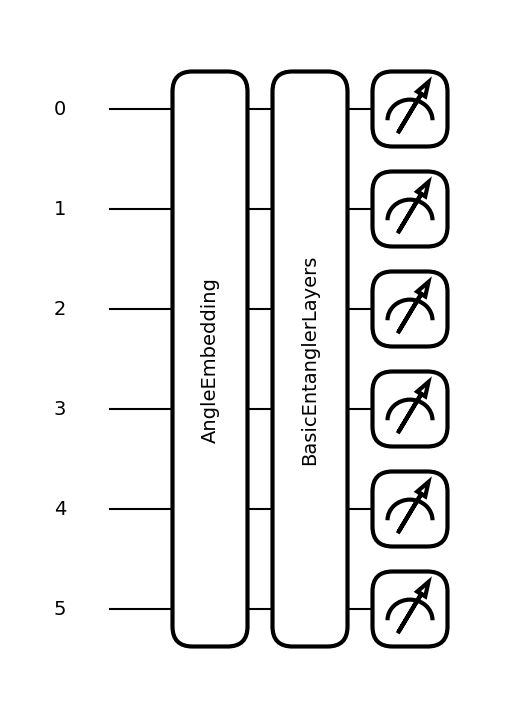

Sequential(
  (0): Linear(in_features=23, out_features=6, bias=True)
  (1): AngleRescale()
  (2): <Quantum Torch Layer: func=circuit>
  (3): Linear(in_features=6, out_features=1, bias=True)
)


In [3]:
import pennylane as qml

N_QUBITS, DEPTH = 6, 3
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev)
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

fig, ax = qml.draw_mpl(circuit)(np.zeros(N_QUBITS), np.zeros((DEPTH, N_QUBITS)))
plt.show()

model = build_model(n_qubits=N_QUBITS, depth=DEPTH)
ckpt = sorted((ROOT / "results" / "checkpoints").glob("hybrid_6q_d3_e400_valmae*.pt"))[0]
model.load_state_dict(torch.load(ckpt, weights_only=True))
print(model)

## 4. Training

MSE loss, Adam. Every run was logged to `results/experiments.csv`. The sweep covered qubit count (4/6/8), circuit depth (1–5), and learning rate — **depth mattered, width didn't**.

In [4]:
log = pd.read_csv(ROOT / "results" / "experiments.csv")
log[["model_name", "val_mae", "test_mae", "n_qubits", "depth", "lr", "epochs"]]

,model_name,val_mae,test_mae,n_qubits,depth,lr,epochs
0,sanity_200,148.6436,NaN,4.0,2.0,0.0010,20.0
1,krr_laplacian,10.7413,10.7593,NaN,NaN,NaN,NaN
2,hybrid_4q_d2_full,21.7316,NaN,4.0,2.0,0.0010,200.0
3,hybrid_4q_d2_lr5e4,22.5560,NaN,4.0,2.0,0.0005,200.0
4,hybrid_4q_d1,22.5751,NaN,4.0,1.0,0.0010,200.0
5,hybrid_6q_d2,21.4262,NaN,6.0,2.0,0.0010,200.0
6,hybrid_6q_d3,16.9150,NaN,6.0,3.0,0.0010,200.0
7,hybrid_8q_d2,21.6515,NaN,8.0,2.0,0.0010,200.0
8,hybrid_6q_d4,20.3167,NaN,6.0,4.0,0.0010,200.0
9,hybrid_6q_d5,17.2975,NaN,6.0,5.0,0.0010,200.0


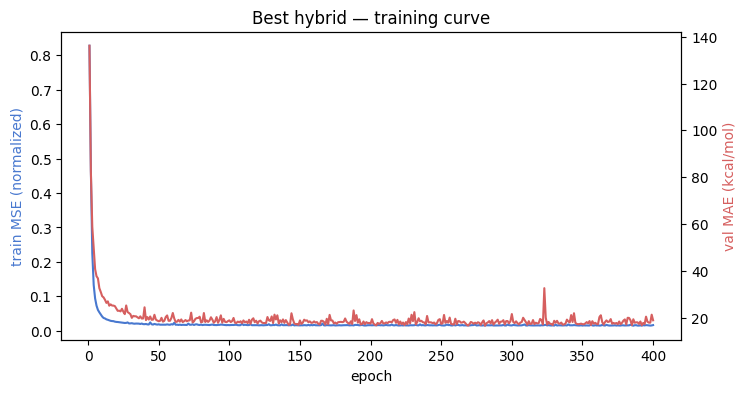

In [5]:
hist = pd.read_csv(ROOT / "results" / "history" / "hybrid_6q_d3_e400.csv")
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(hist.epoch, hist.train_mse, color="#4878cf")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train MSE (normalized)", color="#4878cf")
ax2 = ax1.twinx()
ax2.plot(hist.epoch, hist.val_mae_kcal, color="#d65f5f")
ax2.set_ylabel("val MAE (kcal/mol)", color="#d65f5f")
ax1.set_title("Best hybrid — training curve")
plt.show()

## 5. Results

In [6]:
def latest_test_mae(name):
    rows = log[(log.model_name == name) & log.test_mae.notna()]
    return rows.test_mae.iloc[-1]

table = pd.DataFrame({
    "Model": ["KRR (Laplacian kernel)", "Hybrid quantum (6q, depth 3)", "Classical ablation (same shape)"],
    "Input": ["23 eigenvalues"] * 3,
    "Test MAE (kcal/mol)": [latest_test_mae("krr_laplacian"),
                             latest_test_mae("hybrid_6q_d3_e400_TEST"),
                             latest_test_mae("ablation_6q_d3")],
})
table["vs chemical accuracy (1.0)"] = (table["Test MAE (kcal/mol)"] / 1.0).round(1)
table

,Model,Input,Test MAE (kcal/mol),vs chemical accuracy (1.0)
0,KRR (Laplacian kernel),23 eigenvalues,10.7593,10.8
1,"Hybrid quantum (6q, depth 3)",23 eigenvalues,16.0464,16.0
2,Classical ablation (same shape),23 eigenvalues,16.1339,16.1


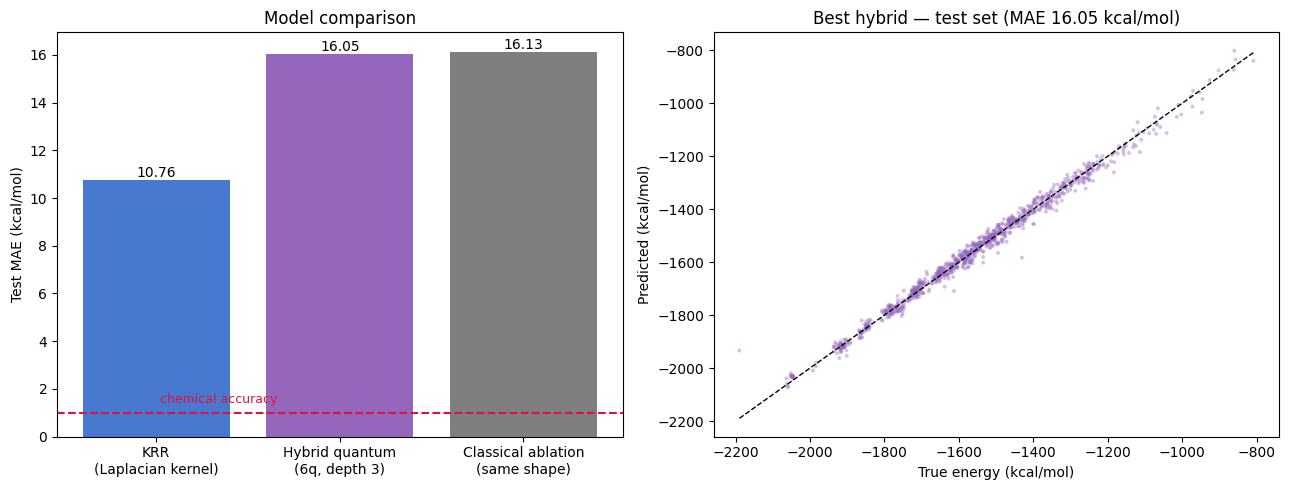

In [7]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 5))

bars = axl.bar(table.Model.str.replace(" (", "\n(", regex=False), table["Test MAE (kcal/mol)"],
               color=["#4878cf", "#9467bd", "#7f7f7f"])
axl.bar_label(bars, fmt="%.2f")
axl.axhline(1.0, color="crimson", linestyle="--")
axl.text(0.02, 1.4, "chemical accuracy", color="crimson", fontsize=9)
axl.set_ylabel("Test MAE (kcal/mol)"); axl.set_title("Model comparison")

model.eval()
with torch.no_grad():
    pred = model(X_test).numpy().ravel()
to_kcal = lambda a: a * meta["y_std"] + meta["y_mean"]
y_true, y_pred = to_kcal(y_test.numpy().ravel()), to_kcal(pred)
axr.scatter(y_true, y_pred, s=8, alpha=0.4, color="#9467bd", edgecolors="none")
lims = [y_true.min(), y_true.max()]
axr.plot(lims, lims, "k--", linewidth=1)
axr.set_xlabel("True energy (kcal/mol)"); axr.set_ylabel("Predicted (kcal/mol)")
axr.set_title(f"Best hybrid — test set (MAE {np.abs(y_true - y_pred).mean():.2f} kcal/mol)")
plt.tight_layout(); plt.show()

## 6. Conclusions

1. **The quantum layer did not help at this scale.** The hybrid model (16.05 kcal/mol) ties its classical twin (16.13) within noise — while costing ~40× the training time (469 s vs 12 s for 400 epochs). This is the central, honest finding of the MVP.
2. **Both neural models trail the KRR baseline (10.76) by ~5 kcal/mol.** The Linear(23→6) encoder bottleneck discards information the kernel method uses in full — the constraint is the architecture's width, not the quantum circuit.
3. **Depth beat width in the sweep:** going from depth 2 to 3 cut MAE by 22%, while adding qubits (4→8) at fixed depth changed nothing.
4. **Our pipeline reproduces the literature:** KRR at 10.76 kcal/mol matches the published ~10 kcal/mol for eigenvalue features, validating data handling end to end. The often-quoted ~3 kcal/mol results require richer molecular representations.
5. **Chemical accuracy (< 1.0 kcal/mol) is unreachable with eigenvalue features** for any model class tested. A follow-up direction: richer inputs (sorted Coulomb matrices, SOAP/SchNet-style descriptors) and quantum layers wide enough to avoid the encoder bottleneck.

**Hypotheses for why quantum didn't help:** (a) the 6-qubit circuit's function class is well within what a linear layer + tanh already covers at this width; (b) angle encoding of 6 compressed features may lose the geometry that would let entanglement shine; (c) QM7's eigenvalue→energy map may simply be too smooth to require quantum expressivity.